# Objective Functions

\begin{equation}
    F_1=\max \sum_{i=1}^{|I|} (\alpha_B Bio_i + \beta_B \tilde{E_i}) \cdot x_i
\end{equation}

\begin{equation}
    F_2 = \max \sum_{i \in I} \tilde{Car}_i \cdot x_i
\end{equation}

\begin{equation}
    F_3 = \max \sum_{i \in I} \tilde{U}_i \cdot x_i
\end{equation}

\begin{equation}
    F_4 = \min \sum_{i \in I} \tilde{Rev}_i \cdot x_i
\end{equation}

\begin{equation}
    F_5 = \min \phi
\end{equation}

# Constraints

\begin{equation}
    \sum_{i\in I}c_i\cdot x_i\leq B
\end{equation}

\begin{equation}
    x_i\leq A_i\cdot y_i\quad \forall i\in I
\end{equation}

\begin{equation}
  x_i\geq m\cdot y_i  \quad \forall i \in I
\end{equation}

\begin{equation}
    c_i \cdot x_i \leq \theta \cdot B \quad \forall i \in I
\end{equation}

\begin{equation}
   \sum_{i\in I}x_i\leq K 
\end{equation}

\begin{equation}
   \sum_{i\in I}y_i\geq \varepsilon M 
\end{equation}

\begin{equation}
    \sum_{i \in I_{arc}} c_i \cdot x_i \ge 12,350,000
\end{equation}

\begin{equation}
    \phi\geq \sum_{i = 1}^{|I|-1} \sum_{j=i+1}^{|I|} \frac{z_{i, j}}{d_{i, j}}
\end{equation}

\begin{equation}
    \phi \geq 0
\end{equation}

\begin{equation}
    z_{i, j} \geq y_i + y_j -1 \quad \forall i < j
\end{equation}

\begin{equation}
    z_{i, j} \leq y_i, \quad z_{i, j} \leq y_j \quad \forall i <j
\end{equation}

\begin{equation}
    F_j\geq F_j^*\quad j=1,2,3\quad (\text{applied sequentially when solving }F_{j+1})
\end{equation}

\begin{equation}
    x_i\geq0,\quad y_i\in \{0,1\}\quad **z_{i, j} \in \{0, 1\} \quad \forall i \in I \quad **\forall j \in J
\end{equation}


In [1]:
from math import floor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

# load the data
df = pd.read_csv("Data\\MPAA_model_data.csv")

df['carbon index norm'] = df['carbon index norm'].fillna(df['carbon index norm'].mean())

# List of municipalities IDs
municipalities = df['NM_MUN'].tolist()

# Biodiversity score for each municipality Bio_i
Bio = df.set_index('NM_MUN')['biodiversity_priority_index'].to_dict()

# Extinction risk normalised E_hat_i
E_hat = df.set_index('NM_MUN')['Extinction risk score norm'].to_dict()

# Carbon sequestration potential for each municipality Car_hat_i
Car_hat = df.set_index('NM_MUN')['carbon index norm'].to_dict()

# Land available for planting in each municipality A_i
A = df.set_index('NM_MUN')['eligible_area_ha_mapbiomas'].to_dict()

# Urgency score U_hat_i
U_hat = df.set_index('NM_MUN')['urgency_5yr_index'].to_dict()

# Reversal risk Rev_hat_i
Rev_hat = df.set_index('NM_MUN')['reversal_risk'].to_dict()

# cost per hectare for each municipality c_i
c = df.set_index('NM_MUN')['cost_per_ha'].to_dict()

# max cost per hectare across all municipalities (for cost-effectiveness)
c_max = max(c.values())
c_max

# ========================= Fixed Additional Parameters ======================== 
B = 489850000  # Total budget in dollars
m = 200    # Minimum viable project scale in hectares
K = 560000 # Updated based on new data and assumptions - can implement up to 560,000 hectares per year across all municipalities
N_min = 25       # Minimum number of municipalities to fund (Fairness constraint)
theta = 0.20  # No municipality can receive more than 20% of the total budget B

# weight constraints
alpha_B = 0.5      # Weight for Biodiversity
beta_B = 0.5       # Weight for Extinction Risk


In [3]:
arc_municipalities = [
    "Abaetetuba",
    "Abel Figueiredo",
    "Acará",
    "Ananindeua",
    "Aurora do Pará",
    "Bagre",
    "Baião",
    "Barcarena",
    "Belém",
    "Benevides",
    "Bom Jesus do Tocantins",
    "Brejo Grande do Araguaia",
    "Breu Branco",
    "Bujaru",
    "Cametá",
    "Canaã dos Carajás",
    "Conceição do Araguaia",
    "Concórdia do Pará",
    "Curionópolis",
    "Eldorado do Carajás",
    "Floresta do Araguaia",
    "Goianésia do Pará",
    "Igarapé-Miri",
    "Inhangapi",
    "Irituia",
    "Itupiranga",
    "Jacundá",
    "Limoeiro do Ajuru",
    "Mãe do Rio",
    "Marituba",
    "Mocajuba",
    "Moju",
    "Nova Ipixuna",
    "Oeiras do Pará",
    "Palestina do Pará",
    "Piçarra",
    "Salvaterra",
    "Santa Bárbara do Pará",
    "Santa Izabel do Pará",
    "São Domingos do Araguaia",
    "São Domingos do Capim",
    "São Geraldo do Araguaia",
    "São João do Araguaia",
    "Sapucaia",
    "Tailândia",
    "Tomé-Açu",
    "Tucuruí",
    "Xinguara",
    "Água Azul do Norte",
    "Anajás",
    "Anapu",
    "Bannach",
    "Bonito",
    "Breves",
    "Cachoeira do Arari",
    "Castanhal",
    "Chaves",
    "Colares",
    "Cumaru do Norte",
    "Curralinho",
    "Gurupá",
    "Marabá",
    "Melgaço",
    "Muaná",
    "Novo Repartimento",
    "Ourém",
    "Ourilândia do Norte",
    "Pacajá",
    "Parauapebas",
    "Pau D'Arco",
    "Ponta de Pedras",
    "Portel",
    "Porto de Moz",
    "Redenção",
    "Rio Maria",
    "Santa Cruz do Arari",
    "Santa Luzia do Pará",
    "Santa Maria das Barreiras",
    "Santana do Araguaia",
    "Santo Antônio do Tauá",
    "São Caetano de Odivelas",
    "São Félix do Xingu",
    "São Francisco do Pará",
    "São Miguel do Guamá",
    "São Sebastião da Boa Vista",
    "Senador José Porfírio",
    "Soure",
    "Vigia",
    "Capitão Poço",
    "Dom Eliseu",
    "Garrafão do Norte",
    "Ipixuna do Pará",
    "Nova Esperança do Piriá",
    "Paragominas",
    "Rondon do Pará",
    "Ulianópolis",
    "Viseu"]

In [ ]:
dist_df = pd.read_csv("Data\\distance_matrix_named.csv", index_col=0)

# --- 1. SPATIAL PRE-COMPUTATION ---
D_max = 250.0
valid_pairs = []
inv_dist = {}

# Ensure IDs are strings to prevent lookup errors
mun_ids = [str(m) for m in municipalities]
dist_df.index = dist_df.index.astype(str)
dist_df.columns = dist_df.columns.astype(str)

for i in mun_ids:
    for j in mun_ids:
        if i < j: # Ensures we only check each unique pair once
            try:
                dij = float(dist_df.at[i, j])
                if 0 < dij <= D_max:
                    valid_pairs.append((i, j))
                    inv_dist[(i, j)] = 1.0 / dij
            except Exception:
                continue

print(f"Generated {len(valid_pairs)} valid spatial pairs within {D_max}km threshold.")

Generated 2850 valid spatial pairs within 250.0km threshold.


In [6]:
import geopandas as gpd
municipalities_gdf = gpd.read_file("Data\\BR_Municipios_2024.shp")

# Filter Pará and project to metric CRS (meters
para_gdf = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"].copy()
    
len(para_gdf)

144

## Base Model

In [8]:
# --- 2. BASE MODEL CREATION FUNCTION ---
def create_base_model(sense=pulp.LpMaximize):
    model = pulp.LpProblem("PMV_Hierarchical_Model", sense)

    # ==========================================
    # 1. Decision Variables
    # ==========================================
    x = pulp.LpVariable.dicts("x", mun_ids, lowBound=0, cat=pulp.LpContinuous)
    
    y = pulp.LpVariable.dicts("y", mun_ids, cat=pulp.LpBinary)
    
    z = pulp.LpVariable.dicts("z", valid_pairs, lowBound=0, upBound=1, cat=pulp.LpContinuous)

    # ==========================================
    # 2. Core Constraints
    # ==========================================
    # Budget and Capacity Limits
    model += pulp.lpSum(c[i] * x[i] for i in mun_ids) <= B, "Budget_Limit"
    model += pulp.lpSum(x[i] for i in mun_ids) <= K, "Global_Capacity_Limit"
    
    # Geographic Equity Threshold
    model += pulp.lpSum(y[i] for i in mun_ids) >= N_min, "Min_Municipalities"

    # Arc of Deforestation Ring-fenced Minimum
    valid_arc_muns = [i for i in arc_municipalities if str(i) in c]
    model += pulp.lpSum(c[str(i)] * x[str(i)] for i in valid_arc_muns) >= 12350000, "Arc_Minimum"

    # ==========================================
    # 3. Logical Bounds
    # ==========================================
    for i in mun_ids:
        # Cannot restore more than eligible area
        model += x[i] <= A[i] * y[i], f"Upper_Bound_Area_{i}"
        
        # Must meet minimum viable scale if selected
        model += x[i] >= m * y[i], f"Min_Viable_Scale_{i}"

        # No municipality can receive more than theta share of total budget
        model += c[i] * x[i] <= theta * B, f"Max_Budget_Share_{i}"

    # ==========================================
    # 4. Fortet–Glover Linearisation for z_ij
    # ==========================================
    for (i, j) in valid_pairs:
        model += z[(i, j)] <= y[i], f"FG_Upper_i_{i}_{j}"
        model += z[(i, j)] <= y[j], f"FG_Upper_j_{i}_{j}"
        
        # This forces z up to 1 when both y[i] and y[j] are 1
        model += z[(i, j)] >= y[i] + y[j] - 1, f"FG_Lower_{i}_{j}"

    # ==========================================
    # 5. Objective Expressions
    # ==========================================
    # Storing these as lpSum expressions rather than variables saves matrix rows in Gurobi
    obj_bio = pulp.lpSum((alpha_B * Bio[i] + beta_B * E_hat[i]) * x[i] for i in mun_ids)
    obj_urg = pulp.lpSum(U_hat[i] * x[i] for i in mun_ids)
    obj_car = pulp.lpSum(Car_hat[i] * x[i] for i in mun_ids)
    obj_rev = pulp.lpSum(Rev_hat[i] * x[i] for i in mun_ids)
    
    # Spatial penalty is only calculated for pairs within D_max
    obj_spatial = pulp.lpSum(z[(i, j)] * inv_dist[(i, j)] for (i, j) in valid_pairs)

    return model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial

## Nadir Utopia Tolerances

In [13]:
tolerances = pd.read_csv("Outputs\\lexicographic_tolerances.csv")

# Assuming you have your utopia_nadir_values DataFrame loaded, extract the ranges:
range_bio = tolerances.loc[tolerances['Objective'] == 'Bio_and_extinction', 'range'].values[0]
range_car = tolerances.loc[tolerances['Objective'] == 'Carbon', 'range'].values[0]
range_urg = tolerances.loc[tolerances['Objective'] == 'Urgency', 'range'].values[0]
range_rev = tolerances.loc[tolerances['Objective'] == 'Reversal Risk', 'range'].values[0]


print(range_bio, range_car, range_urg, range_rev)

144961.85141067387 188096.17648078152 141952.72071175126 216855.2722493316


## Lexicographic Sequence

In [18]:
# ==========================================
# --- TOLERANCE PARAMETERS ---
# ==========================================
alpha = 0.05  # 5% of the total Utopia-Nadir range

# Extract the ranges:
range_bio = tolerances.loc[tolerances['Objective'] == 'Bio_and_extinction', 'range'].values[0]
range_car = tolerances.loc[tolerances['Objective'] == 'Carbon', 'range'].values[0]
range_urg = tolerances.loc[tolerances['Objective'] == 'Urgency', 'range'].values[0]
range_rev = tolerances.loc[tolerances['Objective'] == 'Reversal Risk', 'range'].values[0]

# Calculate exact absolute tolerances
tol_bio = alpha * range_bio
tol_car = alpha * range_car
tol_urg = alpha * range_urg
tol_rev = alpha * range_rev

print(f"Calculated Absolute Tolerances (alpha = {alpha}):")
print(f" Bio Tolerance: {tol_bio:.2f} | Car Tolerance: {tol_car:.2f} | Urg Tolerance: {tol_urg:.2f} | Rev Tolerance: {tol_rev:.2f}")

# ==========================================
# STEP 1: Maximize Biodiversity & Threat (F1)
# ==========================================
print("\nSolving Step 1: Biodiversity and Threat...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)
model += obj_bio, "Objective_F1"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 1 did not solve to Optimal — status: {status}.")

z1_star = pulp.value(model.objective)
print(f"Optimal Biodiversity & Threat Score (F1): {z1_star:.2f}")
print(f" -> Allowed degradation limit for future steps: >= {z1_star - tol_bio:.2f}")

# ==========================================
# STEP 2: Maximize Carbon Sequestration (F2)
# ==========================================
print("\nSolving Step 2: Carbon Sequestration...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)

# F1 is MAX, so we SUBTRACT the tolerance bound
model += obj_bio >= (z1_star - tol_bio), "Preserve_F1_Biodiversity"
model += obj_car, "Objective_F2"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 2 did not solve to Optimal — status: {status}.")

z2_star = pulp.value(model.objective)
print(f"Optimal Carbon Score (F2): {z2_star:.2f}")
print(f" -> Allowed degradation limit for future steps: >= {z2_star - tol_car:.2f}")

# ==========================================
# STEP 3: Maximize Urgency (F3)
# ==========================================
print("\nSolving Step 3: Maximize Urgency...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)

# F1 and F2 are MAX, so we SUBTRACT the tolerance bounds
model += obj_bio >= (z1_star - tol_bio), "Preserve_F1_Biodiversity"
model += obj_car >= (z2_star - tol_car), "Preserve_F2_Carbon"
model += obj_urg, "Objective_F3"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 3 did not solve to Optimal — status: {status}.")

z3_star = pulp.value(model.objective)
print(f"Optimal Urgency Score (F3): {z3_star:.2f}")
print(f" -> Allowed degradation limit for future steps: >= {z3_star - tol_urg:.2f}")

# ==========================================
# STEP 4: Minimize Reversal Risk (F4)
# ==========================================
print("\nSolving Step 4: Minimizing Reversal Risk...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMinimize)

# Apply previous bounds
model += obj_bio >= (z1_star - tol_bio), "Preserve_F1_Biodiversity"
model += obj_car >= (z2_star - tol_car), "Preserve_F2_Carbon"
model += obj_urg >= (z3_star - tol_urg), "Preserve_F3_Urgency"
model += obj_rev, "Objective_F4"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 4 did not solve to Optimal — status: {status}.")

z4_star = pulp.value(model.objective)
print(f"Optimal Reversal Risk Score (F4): {z4_star:.2f}")
# ==========================================
# STEP 5: Minimize Spatial Connectivity/Dispersion (F5)
# ==========================================
print("\nSolving Step 5: Minimizing Spatial Dispersion...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMinimize)

# Apply all previous bounds
model += obj_bio >= (z1_star - tol_bio), "Preserve_F1_Biodiversity"
model += obj_car >= (z2_star - tol_car), "Preserve_F2_Carbon"
model += obj_urg >= (z3_star - tol_urg), "Preserve_F3_Urgency"
model += obj_rev <= (z4_star + tol_rev), "Preserve_F4_Reversal"
model += obj_spatial, "Objective_F5"

model.solve(pulp.GUROBI(msg=True, MIPGap=0.08, TimeLimit=3600))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 5 did not solve to Optimal — status: {status}.")

z5_star = pulp.value(model.objective)
print(f"Optimal Spatial Score (F5): {z5_star:.4f}")
assert z5_star >= 0, "Spatial score should be non-negative — check distance matrix."

# ==========================================
# FINAL RESULTS OUTPUT (from Step 5)
# ==========================================
print("\n" + "="*50)
print(f"FINAL OPTIMAL ALLOCATION PLAN (Lexicographic Step 5 | Alpha = {alpha})")
print("="*50)

total_spent = 0
total_area = 0
selected_municipalities = []

for i in municipalities:
    if y[i].varValue is not None and y[i].varValue > 0.5:
        area = x[i].varValue
        cost_incurred = c[i] * area
        selected_municipalities.append({
            "Municipality": i,
            "Area_ha": area,
            "Cost": cost_incurred
        })
        total_spent += cost_incurred
        total_area += area
        print(f"{i}: Selected | Restored: {area:,.2f} ha | Cost: US$ {cost_incurred:,.2f}")

print("-" * 50)
print(f"Total Budget Spent: US$ {total_spent:,.2f} / US$ {B:,.2f}")
print(f"Total Area Restored: {total_area:,.2f} ha / {K:,.2f} ha")

Calculated Absolute Tolerances (alpha = 0.05):
 Bio Tolerance: 7248.09 | Car Tolerance: 9404.81 | Urg Tolerance: 7097.64 | Rev Tolerance: 10842.76

Solving Step 1: Biodiversity and Threat...
Optimal Biodiversity & Threat Score (F1): 145998.50
 -> Allowed degradation limit for future steps: >= 138750.41

Solving Step 2: Carbon Sequestration...
Optimal Carbon Score (F2): 137265.55
 -> Allowed degradation limit for future steps: >= 127860.74

Solving Step 3: Maximize Urgency...
Optimal Urgency Score (F3): 97654.43
 -> Allowed degradation limit for future steps: >= 90556.79

Solving Step 4: Minimizing Reversal Risk...
Optimal Reversal Risk Score (F4): 116240.16

Solving Step 5: Minimizing Spatial Dispersion...
Set parameter MIPGap to value 0.08
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical pro

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# SOLUTION ANALYSIS & INTERPRETATION (from Lexicographic Step 5)
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("HIERARCHICAL LEXICOGRAPHIC OPTIMIZATION: SOLUTION ANALYSIS")
print("="*70)

# ── 1. Basic Solution Feasibility ──────────────────────────────────────────────
has_solution = any(
    y[i].varValue is not None and y[i].varValue > 0.5 for i in mun_ids
)

if not has_solution:
    print("ERROR: No feasible solution found.")
    print("Try relaxing gamma tolerances or increasing time limit.")
else:
    print("\n✓ Feasible solution recovered from Step 5.\n")
    
    # ── 2. Extract Solution ─────────────────────────────────────────────────────
    total_spent = 0.0
    total_area = 0.0
    num_selected = 0
    selected = []
    
    for i in mun_ids:
        if y[i].varValue is not None and y[i].varValue > 0.5:
            area = x[i].varValue
            cost_incurred = c[i] * area
            selected.append({
                "Municipality": i,
                "Area_ha": round(area, 2),
                "Cost": round(cost_incurred, 2),
            })
            total_spent += cost_incurred
            total_area += area
            num_selected += 1
    
    # ── 3. Resource Allocation Summary ──────────────────────────────────────────
    print("ALLOCATION SUMMARY")
    print("-" * 70)
    print(f"  Municipalities selected  : {num_selected} / {len(mun_ids)}")
    print(f"  Total area allocated     : {total_area:>15,.1f} ha / {K:>12,.0f} ha")
    print(f"  Area utilization         : {100*total_area/K:>15.2f}%")
    print(f"  Total budget spent       : US$ {total_spent:>12,.2f} / US$ {B:>12,.2f}")
    print(f"  Budget utilization       : {100*total_spent/B:>15.2f}%")
    print(f"  Average cost per ha      : US$ {total_spent/total_area:>12,.2f}")
    
    # ── 4. Objective Values & Preservation Constraints ────────────────────────
    print("\n" + "="*70)
    print("LEXICOGRAPHIC OBJECTIVE VALUES & CONSTRAINT VERIFICATION")
    print("="*70)
    
    actual_bio = pulp.value(obj_bio)
    actual_car = pulp.value(obj_car)
    actual_spatial = pulp.value(obj_spatial)
    actual_urg = pulp.value(obj_urg)
    actual_rev = pulp.value(obj_rev)
    
    # Compute preservation bounds
    bio_lb = z1_star - tol_bio
    car_lb = z2_star - tol_car
    urg_lb = z3_star - tol_urg
    rev_ub = z4_star + tol_rev  # F4 minimized, so upper bound    
    # Verification checks with tolerance
    tol = 1e-4
    checks = [
        ("F1: Biodiversity & Threat (MAX)",      
         actual_bio, z1_star, "≥", bio_lb, actual_bio >= bio_lb - tol, "Primary"),
        ("F2: Carbon Sequestration (MAX)",       
         actual_car, z2_star, "≥", car_lb, actual_car >= car_lb - tol, "Secondary"),
        ("F3: Urgency (MAX)",                    
         actual_urg, z3_star, "≥", urg_lb, actual_urg >= urg_lb - tol, "Tertiary"),
        ("F4: Reversal Risk (MIN)",              
         actual_rev, z4_star, "≤", rev_ub, actual_rev <= rev_ub + tol, "Quaternary"),
        ("F5: Spatial Dispersion (MIN)",         
         actual_spatial, z5_star, "N/A", "Optimized", True, "Primary Objective"),
    ]
    
    print(f"\n{'Objective':<35} {'Actual':<15} {'Bound':<15} {'Status':<10} {'Priority':<15}")
    print("-" * 90)
    
    for name, actual, target, op, bound, passed, priority in checks:
        status_txt = "✓ PASS" if passed else "✗ FAIL"
        if op == "N/A":
            print(f"{name:<35} {actual:>14,.4f} {'(optimized)':<15} {status_txt:<10} {priority:<15}")
        else:
            pct_margin = 100 * (actual - bound) / bound if bound != 0 else 0
            print(f"{name:<35} {actual:>14,.4f} {bound:>14,.4f} {status_txt:<10} {priority:<15}")
    
    # ── 5. Hard Constraint Verification ─────────────────────────────────────────
    print("\n" + "="*70)
    print("HARD CONSTRAINT VERIFICATION")
    print("="*70)
    
    budget_ok = total_spent <= B + 1e-4
    area_ok = total_area <= K + 1e-4
    min_mun_ok = num_selected >= N_min
    arc_ok = True  # Check Arc constraint if available
    
    hard_constraints = [
        ("Budget constraint",          f"US$ {total_spent:,.0f} ≤ US$ {B:,.0f}", 
         budget_ok),
        ("Area capacity constraint",   f"{total_area:,.0f} ha ≤ {K:,.0f} ha", 
         area_ok),
        ("Minimum municipalities",     f"{num_selected} ≥ {N_min}", 
         min_mun_ok),
    ]
    
    print(f"\n{'Constraint':<30} {'Value':<40} {'Status':<10}")
    print("-" * 80)
    for name, value, passed in hard_constraints:
        status = "✓ PASS" if passed else "✗ FAIL"
        print(f"{name:<30} {value:<40} {status:<10}")
    
    # ── 6. Detailed Allocation ──────────────────────────────────────────────────
    print("\n" + "="*70)
    print("SELECTED MUNICIPALITIES (sorted by budget allocation)")
    print("="*70)
    
    selected_df = pd.DataFrame(selected)
    selected_df = selected_df.sort_values("Cost", ascending=False).reset_index(drop=True)
    
    print(f"\n{'#':<4} {'Municipality':<35} {'Area (ha)':<15} {'Budget (US$)':<15}")
    print("-" * 70)
    for idx, row in selected_df.iterrows():
        print(f"{idx+1:<4} {row['Municipality']:<35} {row['Area_ha']:>14,.0f} {row['Cost']:>14,.0f}")
    
    # ── 7. Tolerance Analysis ──────────────────────────────────────────────────
    print("\n" + "="*70)
    print("TOLERANCE & DEGRADATION ANALYSIS")
    print("="*70)
    
    print(f"\nLexicographic Tolerance Parameters: gamma = {alpha:.1%}")
    
    print(f"\n{'Objective':<25} {'Optimal (z*)':<15} {'Actual Value':<15} {'Degradation':<15}")
    print("-" * 70)
    
    deg_1 = (z1_star - actual_bio) / z1_star if z1_star != 0 else 0
    deg_2 = (z2_star - actual_car) / z2_star if z2_star != 0 else 0
    deg_3 = (actual_urg - z3_star) / z3_star if z3_star != 0 else 0  # Urgency maximized
    deg_4 = (actual_rev - z4_star) / z4_star if z4_star != 0 else 0  # Reversal minimized
    
    print(f"{'F1 Biodiversity':<25} {z1_star:>14,.2f} {actual_bio:>14,.2f} {deg_1:>14.2%}")
    print(f"{'F2 Carbon':<25} {z2_star:>14,.2f} {actual_car:>14,.2f} {deg_2:>14.2%}")
    print(f"{'F3 Urgency':<25} {z3_star:>14,.2f} {actual_urg:>14,.2f} {deg_3:>14.2%}")
    print(f"{'F4 Reversal Risk':<25} {z4_star:>14,.2f} {actual_rev:>14,.2f} {deg_4:>14.2%}")
    print(f"{'F5 Spatial':<25} {'N/A':<14} {actual_spatial:>14,.4f} {'(Primary OBJ)':<15}")
    
    # ── 8. Save Results ────────────────────────────────────────────────────────
    print("\n" + "="*70)
    #selected_df.to_csv("Outputs/Para Allocations/Hierarchical_Optimal_Allocation.csv", index=False)
    print("="*70 + "\n")


HIERARCHICAL LEXICOGRAPHIC OPTIMIZATION: SOLUTION ANALYSIS

✓ Feasible solution recovered from Step 5.

ALLOCATION SUMMARY
----------------------------------------------------------------------
  Municipalities selected  : 25 / 144
  Total area allocated     :       220,673.4 ha /      560,000 ha
  Area utilization         :           39.41%
  Total budget spent       : US$ 489,850,000.00 / US$ 489,850,000.00
  Budget utilization       :          100.00%
  Average cost per ha      : US$     2,219.80

LEXICOGRAPHIC OBJECTIVE VALUES & CONSTRAINT VERIFICATION

Objective                           Actual          Bound           Status     Priority       
------------------------------------------------------------------------------------------
F1: Biodiversity & Threat (MAX)       140,747.2309   138,750.4102 ✓ PASS     Primary        
F2: Carbon Sequestration (MAX)        127,860.7384   127,860.7384 ✓ PASS     Secondary      
F3: Urgency (MAX)                      90,556.7935    90,556.79

In [17]:
selected_df

,Municipality,Area_ha,Cost_BRL
0,Belterra,46989.61,97970000.00
1,Altamira,40589.37,97970000.00
2,Itaituba,42829.47,97970000.00
3,Santarém,41853.16,90298977.07
4,São Félix do Xingu,22968.89,52358803.35
5,Belém,18564.47,38002519.28
6,Anapu,3015.47,6564630.22
7,Afuá,462.92,1000094.85
8,Faro,200.00,553854.00
9,Alenquer,200.00,534338.97


## Para Allocation Plot

In [ ]:
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path



def budget_allocation_para_municipality_graphic(alloc_df, obj_name, all_municipalities):
    allocation = alloc_df.copy()

    allocation = allocation.merge(
        df[['NM_MUN', 'CD_MUN']],
        left_on='Municipality',
        right_on='NM_MUN',
        how='left'
    )

    # list of municipalities in para
    para_municipalities = municipalities_gdf[municipalities_gdf['NM_UF'] == "Pará"]

    para_municipalities['CD_MUN'] = para_municipalities['CD_MUN'].astype(int)

    # merge the geodataframe with allocation datagrame to get the geometry for each municipality
    para_alloc = para_municipalities.merge(
        allocation,
        left_on='CD_MUN',
        right_on='CD_MUN',
        how='left'
    )
    # check how many municipalities have missing allocations (i.e., not selected in the optimal solution)
    print(para_alloc["Cost"].isna().sum(), "municipalities missing allocations")
    print(len(para_alloc), "total municipalities")

    return para_alloc

def plot_budget_allocation_map(para_alloc, obj_name):
    import matplotlib.ticker as mticker

    para_municipalities = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"]
    funded = para_alloc[para_alloc["Cost"].notna() & (para_alloc["Cost"] > 0)].copy()

    if funded.empty:
        print("No funded municipalities found (Cost > 0).")
        return

    vmin = funded["Cost"].min()
    vmax = funded["Cost"].max()

    fig = plt.figure(figsize=(12, 12))
    ax_map = fig.add_axes([0.05, 0.08, 0.85, 0.84])

    para_municipalities.plot(
        ax=ax_map, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.3
    )

    funded.plot(
        ax=ax_map,
        column="Cost",
        cmap="YlGn",
        edgecolor="#333333",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )

    sm = plt.cm.ScalarMappable(cmap="YlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.03, pad=0.02)
    cbar.set_label("Reforestation Budget (USD)", fontsize=16)
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    cbar.ax.tick_params(labelsize=14)

    ax_map.annotate(
        "N", xy=(0.96, 0.95), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )
    ax_map.annotate(
        "▲", xy=(0.96, 0.92), xycoords="axes fraction",
        ha="center", va="top", fontsize=18
    )

    ax_map.set_title(
        f"Reforestation Budget Allocation Across Pará Municipalities\nObjective: {obj_name}",
        fontsize=18, fontweight="bold", pad=12
    )
    ax_map.set_axis_off()


    # saving the figure to /Figures folder which is a subfolder of the current working directory
    out_dir = Path("Figures/Para Allocation Plots")
    filename = f"Para_Budget_Map_{obj_name.replace(' ', '_')}.png"
    out_path = out_dir / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

c:\Users\alasd\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


119 municipalities missing allocations
144 total municipalities


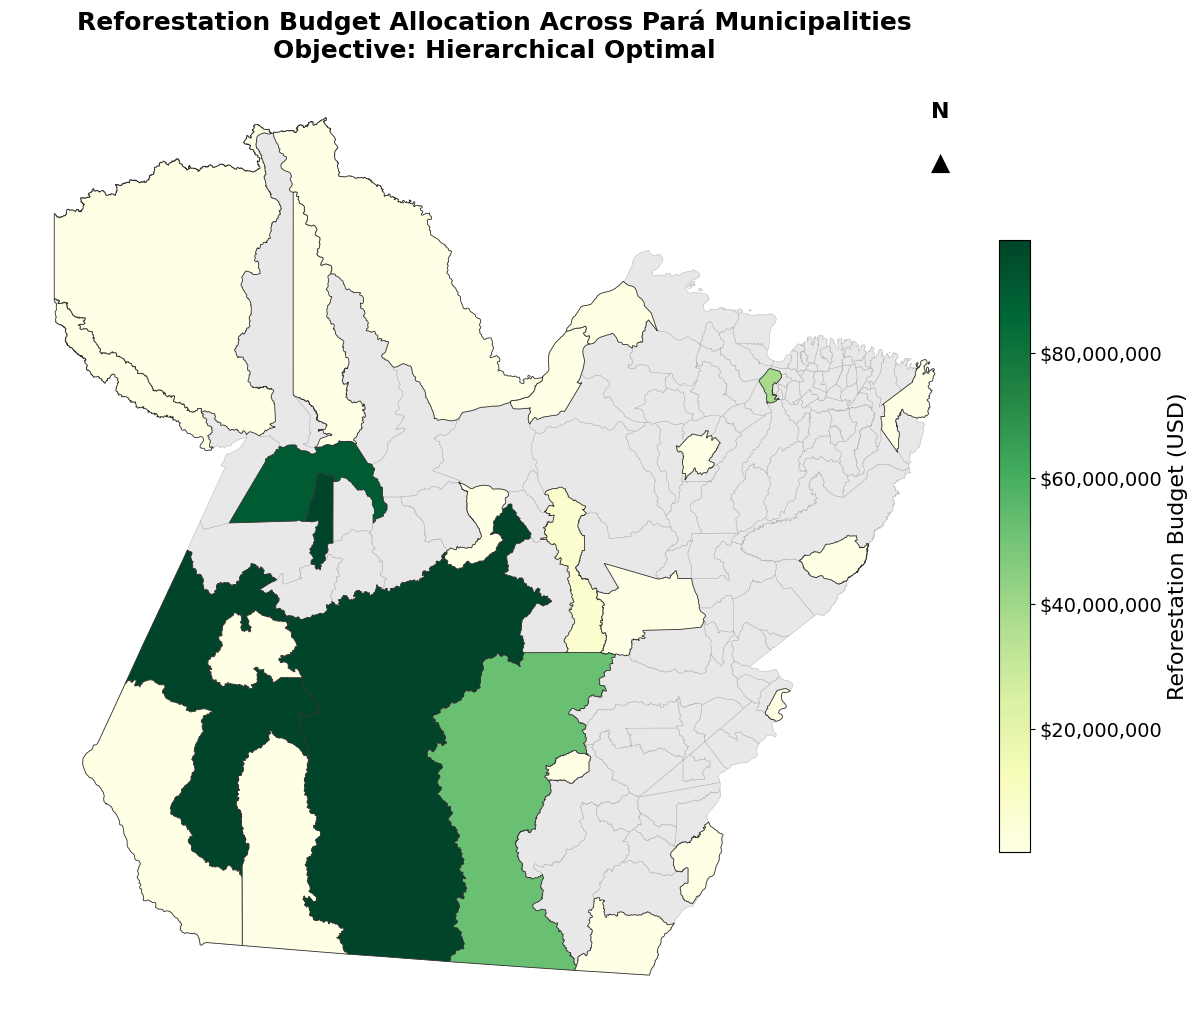

In [20]:
plot_budget_allocation_map(budget_allocation_para_municipality_graphic(selected_df, 'Hierarchical Optimal', municipalities_gdf), 'Hierarchical Optimal')